fit random forest with (almost) all variables and use it for feature selection. 

In [1]:
import pandas as pd
import numpy as np
#from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix #plot_confusion_matrix, 
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt


In [2]:
#read data and drop columns that would generate too many dummy variables in the one-hot encoding
dat = pd.read_parquet('data/votersurvey_cleaned.parquet')
dat = dat.drop(columns = "izip_2016")
dat = dat.drop(columns = "inputstate_2016")


#prepare data
y = dat["presvote16post_2016"]
X = dat.drop(columns = "PARTY_AGENDAS_rand_2016")
#one-hot encode categorical data
X_oh = pd.get_dummies(X, dtype = int)
X_train_oh, X_test_oh, y_train, y_test = train_test_split(X_oh, y, test_size=0.2, random_state=431)

#one-hot encode categorical data
#X_train_oh = pd.get_dummies(X_train, dtype = int)
#X_test_oh = pd.get_dummies(X_test, dtype = int)

In [3]:
X_train_oh.head()

,ft_black_2016,ft_white_2016,ft_hisp_2016,ft_asian_2016,ft_muslim_2016,ft_jew_2016,ft_christ_2016,ft_fem_2016,ft_immig_2016,ft_blm_2016,...,religpew_2016_Buddhist,religpew_2016_Eastern or Greek Orthodox,religpew_2016_Hindu,religpew_2016_Jewish,religpew_2016_Mormon,religpew_2016_Muslim,religpew_2016_Nothing in particular,religpew_2016_Protestant,religpew_2016_Roman Catholic,religpew_2016_Something else
7410,81.0,53.0,91.0,81.0,81.0,84.0,81.000000,74.0,71.0,70.0,...,0,0,0,0,0,0,0,1,0,0
7392,63.0,59.0,60.0,54.0,52.0,61.0,60.000000,59.0,60.0,55.0,...,0,0,0,1,0,0,0,0,0,0
6317,83.0,83.0,83.0,83.0,82.0,83.0,71.000000,83.0,86.0,82.0,...,0,0,0,0,0,0,0,0,0,0
2040,86.0,53.0,89.0,93.0,78.0,84.0,74.214023,72.0,83.0,81.0,...,0,0,0,0,0,0,0,0,0,0
762,90.0,98.0,86.0,100.0,34.0,84.0,99.000000,73.0,53.0,18.0,...,0,0,0,0,0,0,0,0,1,0


In [4]:
X_test_oh.head()

,ft_black_2016,ft_white_2016,ft_hisp_2016,ft_asian_2016,ft_muslim_2016,ft_jew_2016,ft_christ_2016,ft_fem_2016,ft_immig_2016,ft_blm_2016,...,religpew_2016_Buddhist,religpew_2016_Eastern or Greek Orthodox,religpew_2016_Hindu,religpew_2016_Jewish,religpew_2016_Mormon,religpew_2016_Muslim,religpew_2016_Nothing in particular,religpew_2016_Protestant,religpew_2016_Roman Catholic,religpew_2016_Something else
3041,6.0,85.0,31.0,42.0,21.0,50.0,51.0,41.0,10.0,1.0,...,0,0,0,0,0,0,0,0,0,0
2523,94.0,76.0,71.0,90.0,76.0,85.0,86.0,86.0,81.0,100.0,...,0,0,0,0,0,0,0,1,0,0
5096,99.0,98.0,100.0,98.0,100.0,100.0,96.0,78.0,97.0,99.0,...,0,0,0,0,0,0,0,1,0,0
5746,75.0,80.0,76.0,63.0,25.0,79.0,100.0,31.0,35.0,0.0,...,0,0,0,0,0,0,0,1,0,0
1872,99.0,100.0,48.0,56.0,41.0,100.0,76.0,77.0,29.0,26.0,...,0,0,0,1,0,0,0,0,0,0


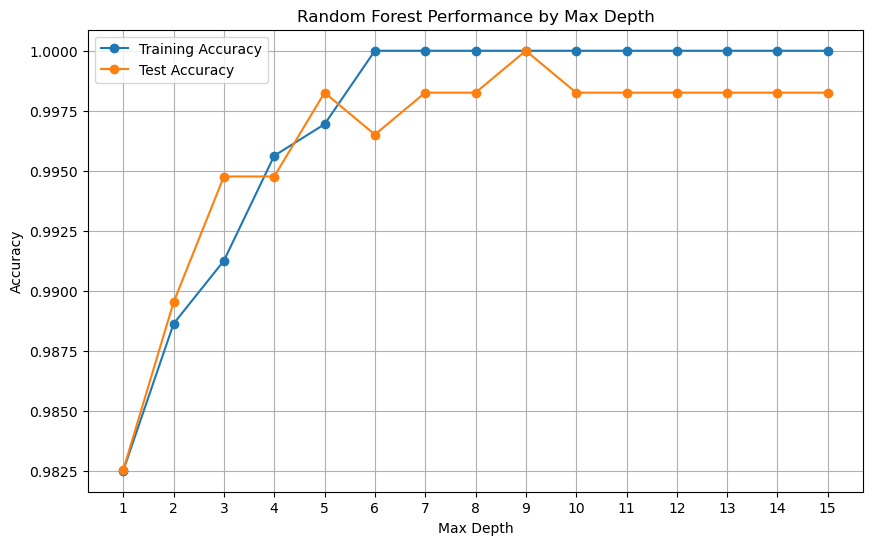

In [5]:
# Initialize lists to store results
depths = list(range(1, 16))
train_accuracies = []
test_accuracies = []

# Run Random Forest for each depth
for i in depths:
    rf = RandomForestClassifier(
        n_estimators=500,
        random_state=123,
        max_depth=i,
        #max_features = 20
    )
    rf.fit(X_train_oh, y_train)

    # Store accuracies
    train_acc = rf.score(X_train_oh, y_train)
    test_acc = rf.score(X_test_oh, y_test)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Create DataFrame for plotting
results_df = pd.DataFrame({
    'max_depth': depths,
    'train_accuracy': train_accuracies,
    'test_accuracy': test_accuracies
})

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(results_df['max_depth'], results_df['train_accuracy'],
         marker='o', label='Training Accuracy')
plt.plot(results_df['max_depth'], results_df['test_accuracy'],
         marker='o', label='Test Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Random Forest Performance by Max Depth')
plt.legend()
plt.grid(True)
plt.xticks(depths)
plt.show()

# Display the DataFrame
#print("\nResults DataFrame:")
#print(results_df)

In [24]:
#attempt with limiting max_features
#don't use
rf = RandomForestClassifier(n_estimators = 1000, random_state = 45, max_depth = 6, max_features = 10)
rf.fit(X_train_oh, y_train)

print(f"Train accuracy depth 9: ", rf.score(X_train_oh, y_train))
print(f"Test accuracy depth 9", rf.score(X_test_oh, y_test)) #heavy overfitting...

Train accuracy depth 9:  0.9790209790209791
Test accuracy depth 9 0.9825479930191972


                 precision    recall  f1-score   support

   Donald Trump       1.00      1.00      1.00       253
Hillary Clinton       1.00      1.00      1.00       320

       accuracy                           1.00       573
      macro avg       1.00      1.00      1.00       573
   weighted avg       1.00      1.00      1.00       573



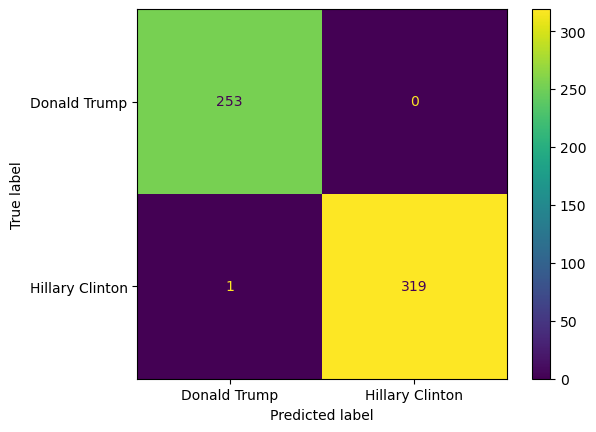

In [31]:
# run random forest with prefered depth and create confusion matrix
rf = RandomForestClassifier(n_estimators = 1000, random_state = 45, max_depth = 5)
rf.fit(X_train_oh, y_train)

y_pred = rf.predict(X_test_oh)
cmat = confusion_matrix(y_test, y_pred, labels = rf.classes_)
ConfusionMatrixDisplay(cmat, display_labels = rf.classes_).plot()

#classification report
print(classification_report(y_test, y_pred))

In [32]:
#extract feature importance and regroup by dummy variable
#e. g. sum over the rows "presvote16post_2016_Hillary Clinton" and "presvote16post_2016_Donald Trump"

#this can be used for feature selection


#create df
imp = rf.feature_importances_
imp_names = rf.feature_names_in_
imp_df = pd.DataFrame({"imp" : imp, "imp_names" : imp_names})

# Extract the base name (everything before the last underscore)
imp_df["base_name"] = imp_df["imp_names"].str.rsplit('_', n=1).str[0]

# Group by base_name and sum the 'imp' values
imp_df_grouped = imp_df.groupby("base_name", as_index=False)["imp"].sum().sort_values("imp", ascending = False)
imp_df_grouped = imp_df_grouped.rename(columns = {"imp": "imp_grouped"})

imp_df_grouped.head(25)

,base_name,imp_grouped
133,presvote16post_2016,0.152262
2,Clinton_Cruz_2016,0.088848
16,Sanders_Trump_2016,0.086568
3,Clinton_Rubio_2016,0.076040
53,fav_trump_2016,0.061549
47,fav_hrc_2016,0.050801
82,healthreformbill_2016,0.045828
15,Sanders_Rubio_2016,0.041753
48,fav_obama_2016,0.041201
121,obamaapp_2016,0.033880


In [33]:
#individual feature importances for comparison
imp_df.sort_values("imp", ascending = False).head(25)

,imp,imp_names,base_name
33,0.080857,presvote16post_2016_Hillary Clinton,presvote16post_2016
30,0.071404,presvote16post_2016_Donald Trump,presvote16post_2016
42,0.057525,Clinton_Cruz_2016_Hillary Clinton (Democratic),Clinton_Cruz_2016
69,0.051478,fav_trump_2016_Very unfavorable,fav_trump_2016
39,0.046360,Clinton_Rubio_2016_Hillary Clinton (Democratic),Clinton_Rubio_2016
94,0.044971,fav_hrc_2016_Very unfavorable,fav_hrc_2016
46,0.043254,Sanders_Trump_2016_Donald Trump (Republican),Sanders_Trump_2016
44,0.043016,Sanders_Trump_2016_Bernie Sanders (Democratic),Sanders_Trump_2016
43,0.029740,Clinton_Cruz_2016_Ted Cruz (Republican),Clinton_Cruz_2016
40,0.029268,Clinton_Rubio_2016_Marco Rubio (Republican),Clinton_Rubio_2016
